# 🛒 Superstore Sales — Exploratory Data Analysis

**Dataset:** Superstore (9,994 orders · 793 customers · 2014–2017)  
**Goal:** Understand sales trends, product profitability, customer segments, and the impact of discounting.

---
### Sections
1. Setup & Data Loading  
2. Data Overview & Quality Check  
3. Sales & Profit Trends  
4. Category & Sub-Category Analysis  
5. Regional & Segment Performance  
6. Discount Impact Analysis  
7. Customer Analysis  
8. Key Takeaways


## 1. Setup & Data Loading

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

In [84]:
df = pd.read_csv('Superstore.csv', encoding='latin1')

# Strip BOM from first column name if present
df.columns = [c.lstrip('\ufeff').strip() for c in df.columns]

# Parse dates (mixed format: MM-DD-YY and M/D/YYYY)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='mixed')

# Derived columns
df['Year']         = df['Order Date'].dt.year
df['Month']        = df['Order Date'].dt.month
df['Quarter']      = df['Order Date'].dt.quarter
df['Ship Days']    = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin'] = df['Profit'] / df['Sales'].replace(0, np.nan)

print(f"Shape: {df.shape}")
df.head()

Shape: (9994, 26)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Ship Days,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4,3,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4,3,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2,4,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4,7,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4,7,0.1125


## 2. Data Overview & Quality Check

In [85]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [86]:
# Descriptive statistics for numeric columns
df[['Sales', 'Quantity', 'Discount', 'Profit', 'Ship Days']].describe().round(2)

,Sales,Quantity,Discount,Profit,Ship Days
count,9994.00,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66,3.96
std,623.25,2.23,0.21,234.26,1.75
min,0.44,1.00,0.00,-6599.98,0.00
25%,17.28,2.00,0.00,1.73,3.00
50%,54.49,3.00,0.20,8.67,4.00
75%,209.94,5.00,0.20,29.36,5.00
max,22638.48,14.00,0.80,8399.98,7.00


In [87]:
# Missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None ✓")

Missing values per column:
None ✓


In [88]:
# Duplicate orders
print(f"Duplicate rows      : {df.duplicated().sum()}")
print(f"Unique Order IDs    : {df['Order ID'].nunique():,}")
print(f"Unique Customers    : {df['Customer ID'].nunique():,}")
print(f"Unique Products     : {df['Product ID'].nunique():,}")
print(f"Date range          : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")

Duplicate rows      : 0
Unique Order IDs    : 5,009
Unique Customers    : 793
Unique Products     : 1,862
Date range          : 2014-01-03 → 2017-12-30


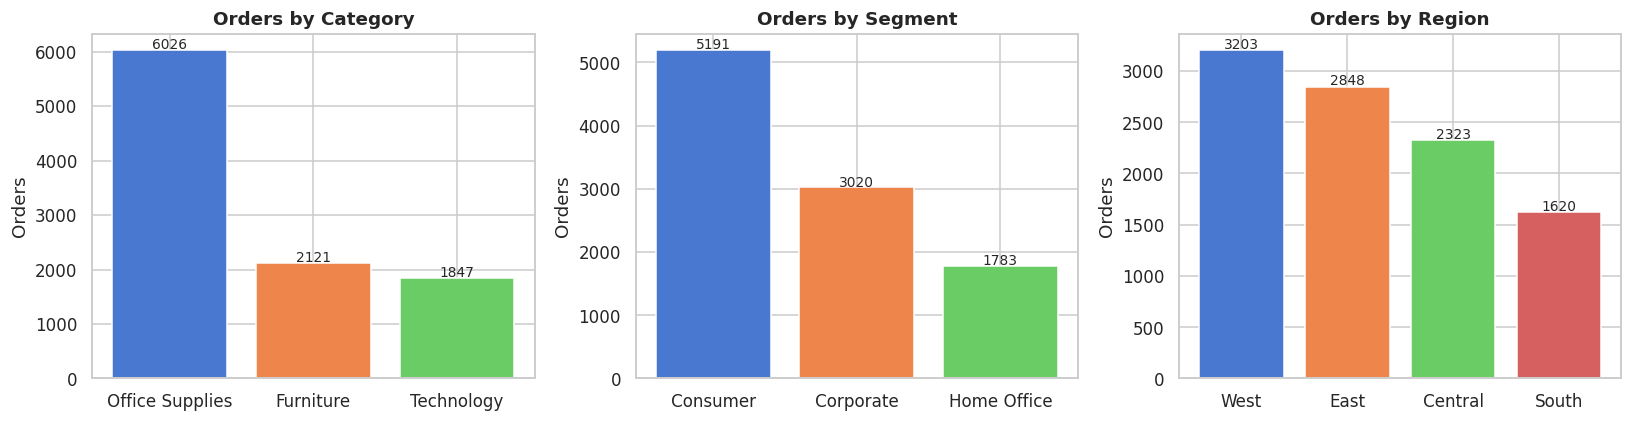

In [89]:
# Category distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Category', 'Segment', 'Region']):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
    ax.set_title(f'Orders by {col}', fontweight='bold')
    ax.set_ylabel('Orders')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Sales & Profit Trends

In [90]:
# Yearly summary
yearly = df.groupby('Year').agg(
    Revenue  = ('Sales',    'sum'),
    Profit   = ('Profit',   'sum'),
    Orders   = ('Order ID', 'nunique')
).reset_index()
yearly['Margin %'] = (yearly['Profit'] / yearly['Revenue'] * 100).round(1)
yearly

,Year,Revenue,Profit,Orders,Margin %
0,2014,484247.4981,49543.9741,969,10.2
1,2015,470532.5090,61618.6037,1038,13.1
2,2016,609205.5980,81795.1743,1315,13.4
3,2017,733215.2552,93439.2696,1687,12.7


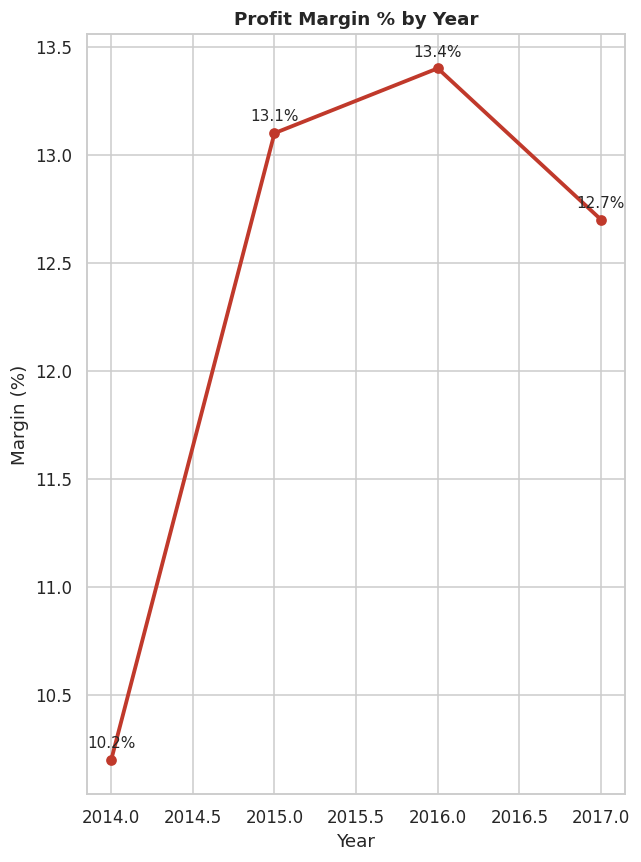

In [91]:
fig, axes = plt.subplots(figsize=(6, 8))

# Profit Margin trend
axes.plot(yearly['Year'], yearly['Margin %'], marker='o', color='#C0392B', linewidth=2.5)
axes.set_title('Profit Margin % by Year', fontweight='bold')
axes.set_ylabel('Margin (%)')
axes.set_xlabel('Year')
for _, row in yearly.iterrows():
    axes.annotate(f"{row['Margin %']}%", (row['Year'], row['Margin %']),
                     textcoords='offset points', xytext=(0, 8), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

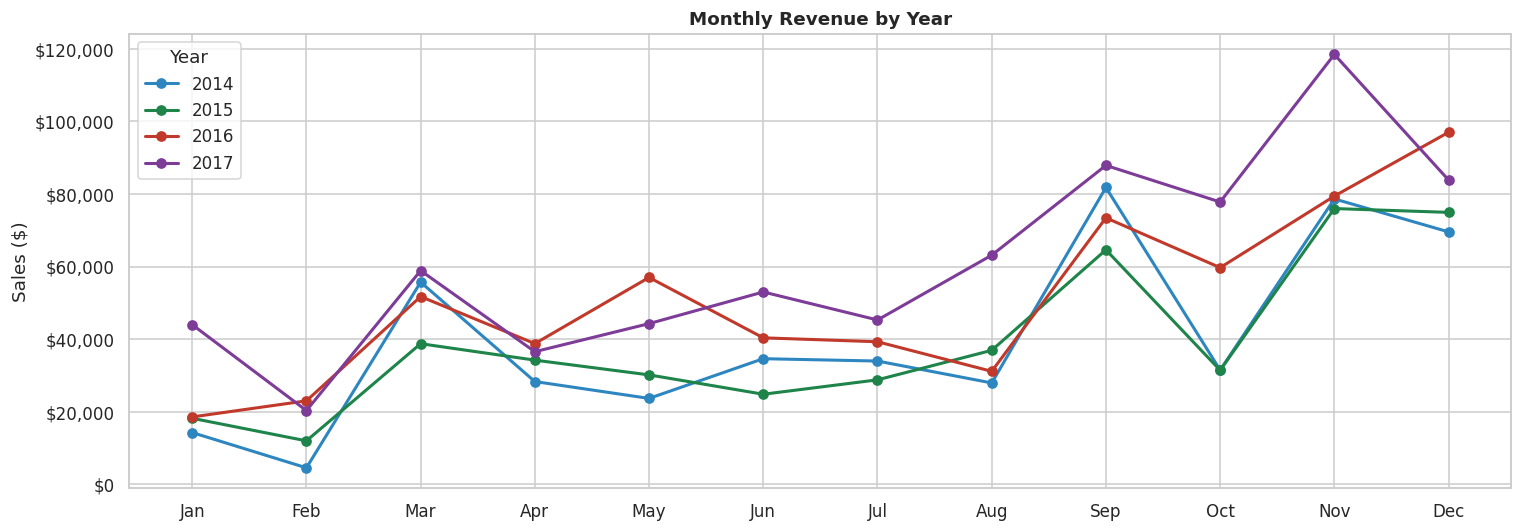

In [92]:
# Monthly revenue trend (all years overlaid)
monthly = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2E86C1', '#1E8449', '#C0392B', '#7D3C98']
for i, year in enumerate(sorted(monthly['Year'].unique())):
    data = monthly[monthly['Year'] == year]
    ax.plot(data['Month'], data['Sales'], marker='o', label=str(year),
            color=colors[i], linewidth=2)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Monthly Revenue by Year', fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Year')
plt.tight_layout()
plt.show()

## 4. Category & Sub-Category Analysis

In [93]:
cat = df.groupby('Category').agg(
    Revenue  = ('Sales',  'sum'),
    Profit   = ('Profit', 'sum'),
    Orders   = ('Order ID', 'nunique')
).reset_index()
cat['Margin %'] = (cat['Profit'] / cat['Revenue'] * 100).round(1)
cat.sort_values('Revenue', ascending=False)

,Category,Revenue,Profit,Orders,Margin %
2,Technology,836154.0330,145454.9481,1544,17.4
0,Furniture,741999.7953,18451.2728,1764,2.5
1,Office Supplies,719047.0320,122490.8008,3742,17.0


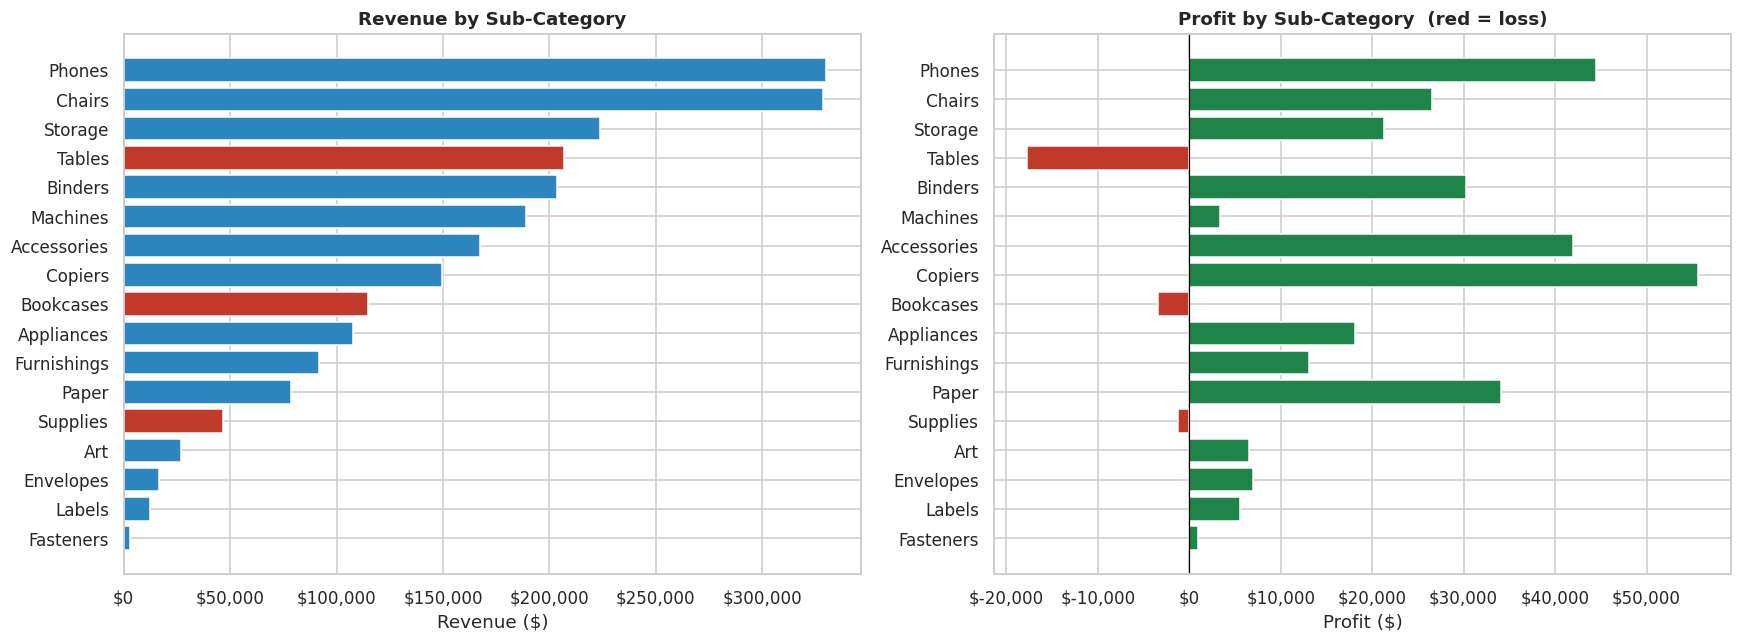

In [94]:
subcat = df.groupby(['Category', 'Sub-Category']).agg(
    Revenue = ('Sales',  'sum'),
    Profit  = ('Profit', 'sum')
).reset_index()
subcat['Margin %'] = (subcat['Profit'] / subcat['Revenue'] * 100).round(1)
subcat = subcat.sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by Sub-Category
colors = ['#C0392B' if p < 0 else '#2E86C1' for p in subcat['Profit']]
axes[0].barh(subcat['Sub-Category'], subcat['Revenue'], color=colors)
axes[0].set_title('Revenue by Sub-Category', fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].invert_yaxis()

# Profit by Sub-Category
colors2 = ['#C0392B' if p < 0 else '#1E8449' for p in subcat['Profit']]
axes[1].barh(subcat['Sub-Category'], subcat['Profit'], color=colors2)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Profit by Sub-Category  (red = loss)', fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

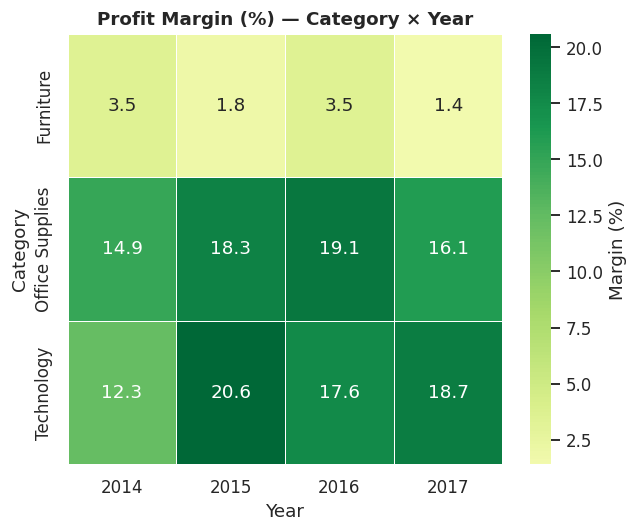

In [95]:
# Profit margin heatmap — Category × Year
pivot = df.groupby(['Category', 'Year']).apply(
    lambda x: x['Profit'].sum() / x['Sales'].sum() * 100
).unstack().round(1)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Margin (%)'})
ax.set_title('Profit Margin (%) — Category × Year', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Regional & Segment Performance

In [96]:
region = df.groupby('Region').agg(
    Revenue  = ('Sales',  'sum'),
    Profit   = ('Profit', 'sum'),
    Customers = ('Customer ID', 'nunique')
).reset_index()
region['Margin %'] = (region['Profit'] / region['Revenue'] * 100).round(1)
region.sort_values('Revenue', ascending=False)

,Region,Revenue,Profit,Customers,Margin %
3,West,725457.8245,108418.4489,686,14.9
1,East,678781.2400,91522.7800,674,13.5
0,Central,501239.8908,39706.3625,629,7.9
2,South,391721.9050,46749.4303,512,11.9


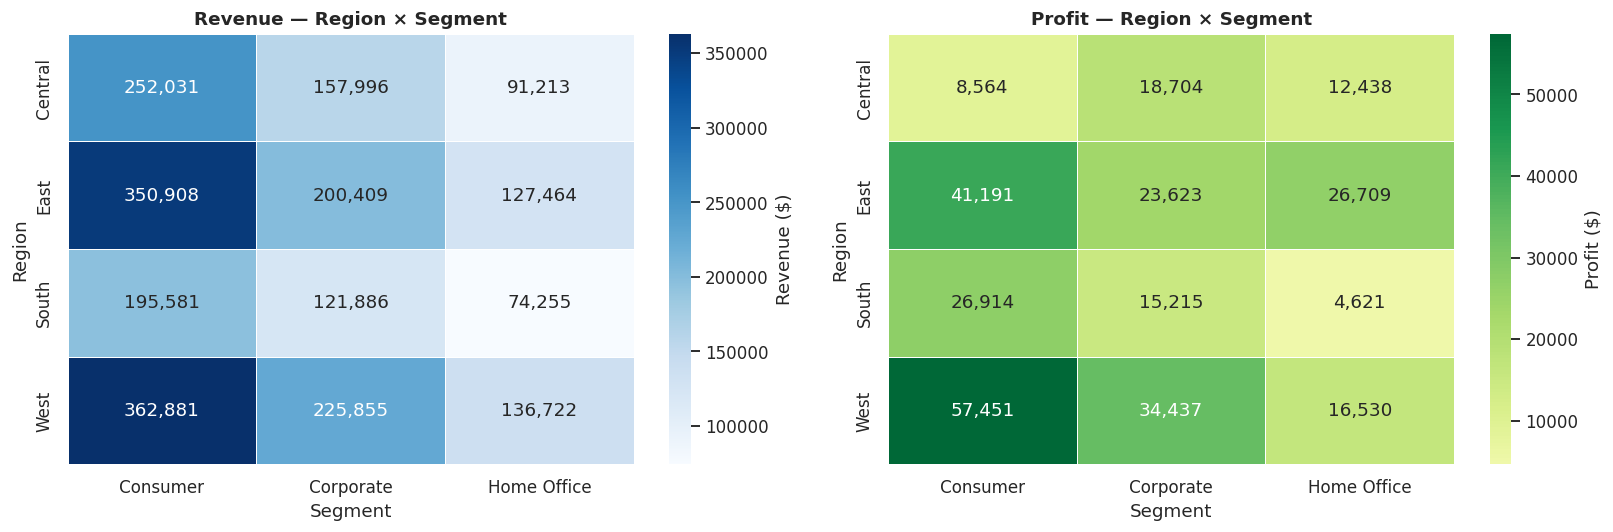

In [97]:
# Region × Segment heatmap
pivot_rs = df.groupby(['Region', 'Segment'])['Sales'].sum().unstack().round(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(pivot_rs, annot=True, fmt=',.0f', cmap='Blues',
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Revenue ($)'})
axes[0].set_title('Revenue — Region × Segment', fontweight='bold')

pivot_profit = df.groupby(['Region', 'Segment'])['Profit'].sum().unstack().round(0)
sns.heatmap(pivot_profit, annot=True, fmt=',.0f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Profit ($)'})
axes[1].set_title('Profit — Region × Segment', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Discount Impact Analysis

In [98]:
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 1.0],
    labels=['No Discount', '1-10%', '11-20%', '21-30%', '31%+']
)

disc = df.groupby('Discount Band', observed=True).agg(
    Transactions = ('Sales',   'count'),
    Avg_Sale     = ('Sales',   'mean'),
    Avg_Profit   = ('Profit',  'mean'),
    Total_Profit = ('Profit',  'sum')
).reset_index().round(2)
disc

,Discount Band,Transactions,Avg_Sale,Avg_Profit,Total_Profit
0,No Discount,4798,226.74,66.90,320987.60
1,1-10%,94,578.40,96.06,9029.18
2,11-20%,3709,213.58,24.74,91756.30
3,21-30%,227,454.74,-45.68,-10369.28
4,31%+,1166,222.59,-107.21,-125006.78


Text(0.5, 0, 'Discount Band')

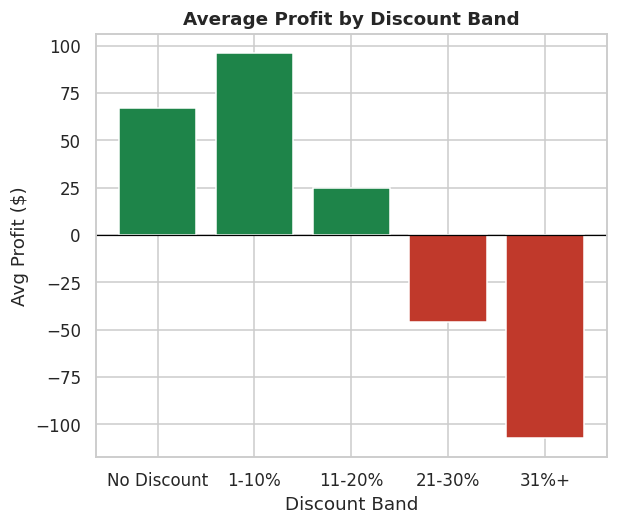

In [99]:
fig, axes = plt.subplots(figsize=(6, 5))

# Average profit per discount band
colors = ['#1E8449' if v >= 0 else '#C0392B' for v in disc['Avg_Profit']]
axes.bar(disc['Discount Band'], disc['Avg_Profit'], color=colors)
axes.axhline(0, color='black', linewidth=0.8)
axes.set_title('Average Profit by Discount Band', fontweight='bold')
axes.set_ylabel('Avg Profit ($)')
axes.set_xlabel('Discount Band')

## 7. Customer Analysis

In [100]:
# Top 10 customers by revenue
top_customers = (
    df.groupby(['Customer ID', 'Customer Name', 'Segment'])
      .agg(Revenue=('Sales','sum'), Profit=('Profit','sum'), Orders=('Order ID','nunique'))
      .reset_index()
      .sort_values('Revenue', ascending=False)
      .head(10)
)
top_customers['Margin %'] = (top_customers['Profit'] / top_customers['Revenue'] * 100).round(1)
top_customers[['Customer Name', 'Segment', 'Revenue', 'Profit', 'Margin %', 'Orders']]

,Customer Name,Segment,Revenue,Profit,Margin %,Orders
700,Sean Miller,Home Office,25043.050,-1980.7393,-7.9,5
741,Tamara Chand,Corporate,19052.218,8981.3239,47.1,5
621,Raymond Buch,Consumer,15117.339,6976.0959,46.1,6
730,Tom Ashbrook,Home Office,14595.620,4703.7883,32.2,4
6,Adrian Barton,Consumer,14473.571,5444.8055,37.6,10
434,Ken Lonsdale,Consumer,14175.229,806.8550,5.7,12
669,Sanjit Chand,Consumer,14142.334,5757.4119,40.7,9
327,Hunter Lopez,Consumer,12873.298,5622.4292,43.7,6
683,Sanjit Engle,Consumer,12209.438,2650.6769,21.7,11
131,Christopher Conant,Consumer,12129.072,2177.0493,17.9,5


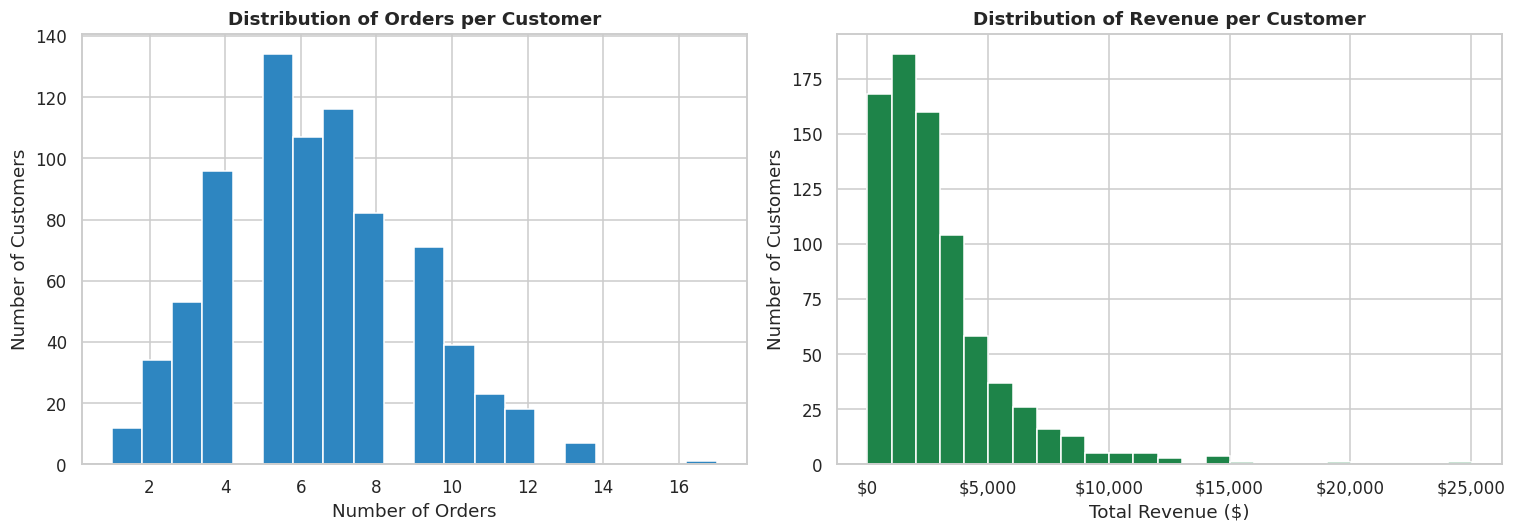

In [101]:
# Customer order frequency distribution
order_freq = df.groupby('Customer ID')['Order ID'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(order_freq, bins=20, color='#2E86C1', edgecolor='white')
axes[0].set_title('Distribution of Orders per Customer', fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')

# Revenue distribution per customer
cust_rev = df.groupby('Customer ID')['Sales'].sum()
axes[1].hist(cust_rev, bins=25, color='#1E8449', edgecolor='white')
axes[1].set_title('Distribution of Revenue per Customer', fontweight='bold')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].set_ylabel('Number of Customers')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [102]:
# Ship mode analysis
ship = df.groupby('Ship Mode').agg(
    Orders    = ('Order ID', 'nunique'),
    Avg_Days  = ('Ship Days', 'mean'),
    Revenue   = ('Sales', 'sum')
).reset_index().round(2)
ship.sort_values('Orders', ascending=False)

,Ship Mode,Orders,Avg_Days,Revenue
3,Standard Class,2994,5.01,1358215.74
2,Second Class,964,3.24,459193.57
0,First Class,787,2.18,351428.42
1,Same Day,264,0.04,128363.12


## 8. Key Takeaways

| # | Finding |
|---|---------|
| 1 | **Revenue grew year-over-year** across all 4 years, but profit margin fluctuates — worth monitoring |
| 2 | **Technology** has the highest profit margin despite not being the highest revenue category |
| 3 | **Furniture (Tables & Bookcases)** are consistent loss-makers — negative profit despite high sales |
| 4 | **Discounts above 20% almost always result in losses** — strong negative correlation with profit |
| 5 | **The West region** generates the most revenue; **the Central region** has the lowest profit margin |
| 6 | **Consumer segment** has the most orders; **Corporate** has a better profit margin per order |
| 7 | A small number of customers (~top 10%) drive a disproportionate share of revenue |
